In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('force_energy_results.csv')
df.head()

,DOC,FEED,I_mean,VB,F_cutting_N,Energy_kWh,cutting_time_min,MRR
0,1.5,0.5,5.438449,0.00,345.890309,0.028091,1.169492,619.5
1,1.5,0.5,5.827789,0.11,370.652669,0.030102,1.169492,619.5
2,1.5,0.5,7.148232,0.20,454.634021,0.036923,1.169492,619.5
3,1.5,0.5,7.490556,0.24,476.406152,0.038691,1.169492,619.5
4,1.5,0.5,7.818537,0.29,497.266020,0.040385,1.169492,619.5


In [3]:
df.describe()

,DOC,FEED,I_mean,VB,F_cutting_N,Energy_kWh,cutting_time_min,MRR
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,1.034483,0.365517,6.160736,0.339379,391.828417,0.047623,1.798597,318.294828
std,0.365173,0.125072,1.589153,0.260542,101.071559,0.017757,0.585082,171.977232
min,0.750000,0.250000,3.239052,0.000000,206.006653,0.016756,1.169492,154.875000
25%,0.750000,0.250000,4.797509,0.150000,305.125897,0.035493,1.169492,154.875000
50%,0.750000,0.250000,6.156138,0.290000,391.535933,0.041884,2.338983,309.750000
75%,1.500000,0.500000,7.744064,0.470000,492.529492,0.057740,2.338983,309.750000
max,1.500000,0.500000,8.870221,1.530000,564.154111,0.091635,2.338983,619.500000


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DOC               145 non-null    float64
 1   FEED              145 non-null    float64
 2   I_mean            145 non-null    float64
 3   VB                145 non-null    float64
 4   F_cutting_N       145 non-null    float64
 5   Energy_kWh        145 non-null    float64
 6   cutting_time_min  145 non-null    float64
 7   MRR               145 non-null    float64
dtypes: float64(8)
memory usage: 9.2 KB


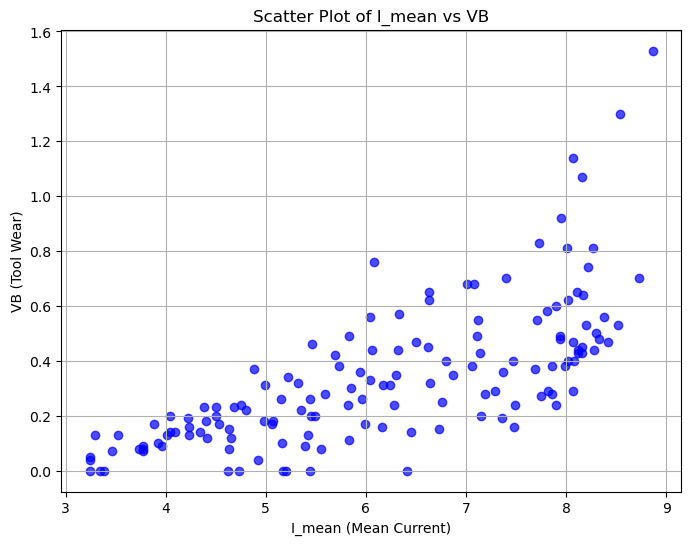

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['I_mean'], df['VB'], alpha=0.7, color='blue')
plt.xlabel('I_mean (Mean Current)')
plt.ylabel('VB (Tool Wear)')
plt.title('Scatter Plot of I_mean vs VB')
plt.grid(True)
plt.show()

In [6]:
df.drop(columns=['MRR'], inplace=True)

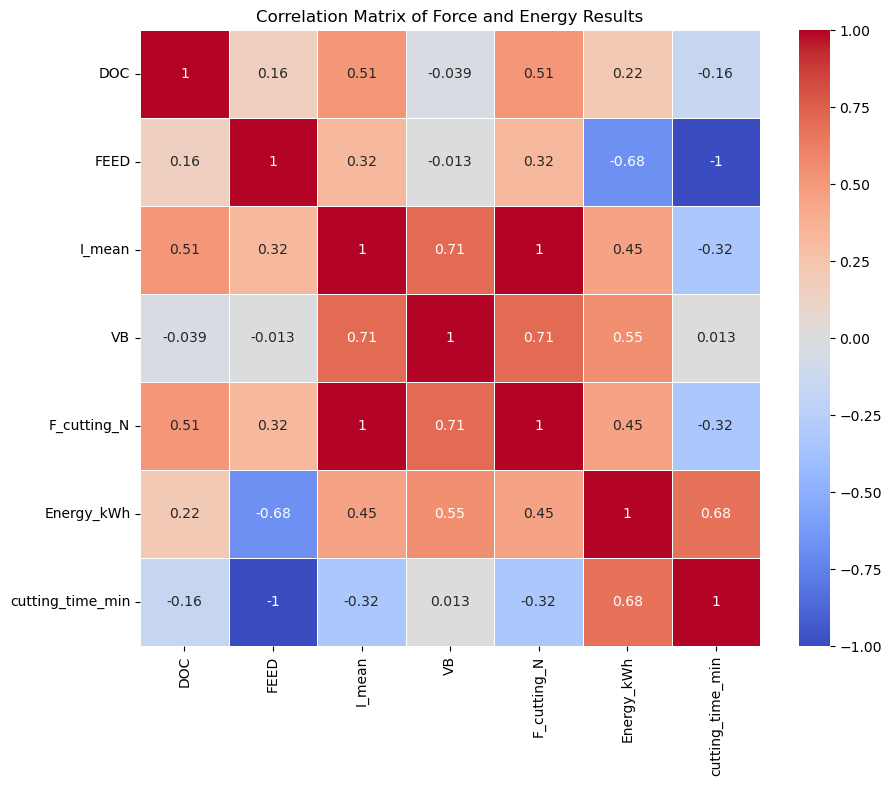

In [7]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Force and Energy Results')
plt.show()

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [69]:
# Features: all columns except VB
X = df.drop(columns=['VB'])
y = df['VB']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (116, 7)
Test set size: (29, 7)


In [70]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Display coefficients (shows feature importance)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-5.03413528e-01 -1.62784993e-02  3.29408049e-05  2.09506505e-03
  3.87454649e+00  7.61502678e-02  4.59902646e-04]
Intercept: -0.4280090418946514


In [71]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

Root Mean Squared Error (Train): 0.11460014206901388
Root Mean Squared Error (Test): 0.13510494423270258
R^2 Score (Train): 0.775236008082085
R^2 Score (Test): 0.820317951402613


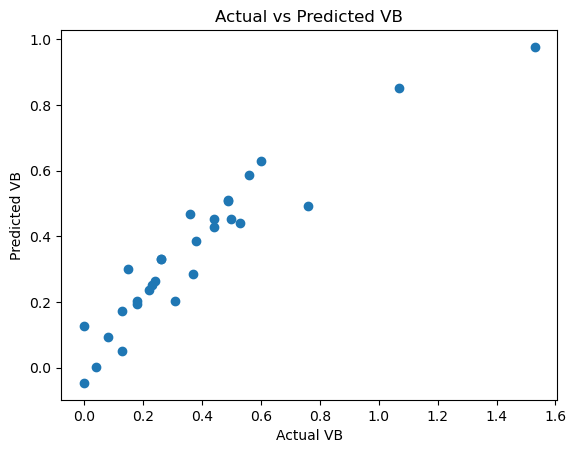

In [72]:
y_pred = model.predict(X_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train,y_train_pred)
print(f"Root Mean Squared Error (Train): {rmse_train}")
print(f"Root Mean Squared Error (Test): {rmse}")
print(f"R^2 Score (Train): {r2_train}")
print(f"R^2 Score (Test): {r2}")

# Plot actual vs predicted (optional visualization)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual VB')
plt.ylabel('Predicted VB')
plt.title('Actual vs Predicted VB')
plt.show()

In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

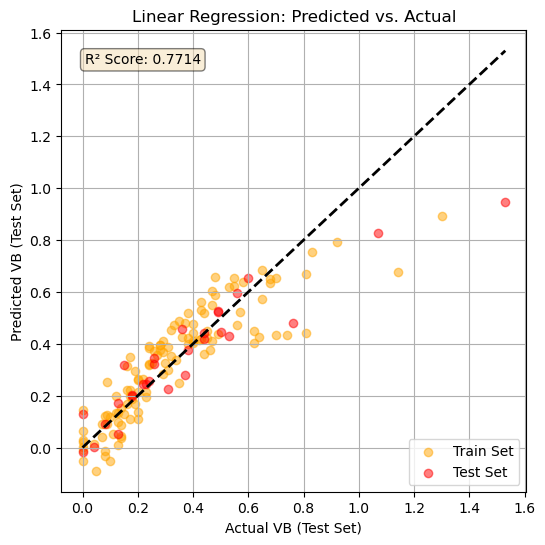

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label="Train Set", color = 'orange')
plt.scatter(y_test, y_test_pred, alpha=0.5, label="Test Set", color = 'red')
plt.xlabel("Actual VB (Test Set)")
plt.ylabel("Predicted VB (Test Set)")
plt.title("Linear Regression: Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.grid(True)
plt.legend()
plt.text(0.05, 0.95, f'R² Score: {r2_train:.4f}', transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import Pipeline

# Scale features for better regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression with cross-validation (finds optimal alpha)
alphas = np.logspace(-3, 3, 100)  # Test alpha values from 0.001 to 1000
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best Alpha (Ridge): {ridge_cv.alpha_}")
ridge_pred = ridge_cv.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
print(f"Ridge R² Score: {ridge_r2:.4f}")
print(f"Ridge MSE: {ridge_mse:.4f}")

# Lasso Regression with cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print(f"\nBest Alpha (Lasso): {lasso_cv.alpha_}")
lasso_pred = lasso_cv.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
print(f"Lasso R² Score: {lasso_r2:.4f}")
print(f"Lasso MSE: {lasso_mse:.4f}")

# ElasticNet Regression with cross-validation (combines Ridge + Lasso)
elasticnet_cv = ElasticNetCV(alphas=alphas, cv=5, max_iter=10000)
elasticnet_cv.fit(X_train_scaled, y_train)

print(f"\nBest Alpha (ElasticNet): {elasticnet_cv.alpha_}")
elasticnet_pred = elasticnet_cv.predict(X_test_scaled)
elasticnet_r2 = r2_score(y_test, elasticnet_pred)
elasticnet_mse = mean_squared_error(y_test, elasticnet_pred)
print(f"ElasticNet R² Score: {elasticnet_r2:.4f}")
print(f"ElasticNet MSE: {elasticnet_mse:.4f}")

Best Alpha (Ridge): 5.72236765935022
Ridge R² Score: 0.7860
Ridge MSE: 0.0217

Best Alpha (Lasso): 0.003511191734215131
Lasso R² Score: 0.7896
Lasso MSE: 0.0214

Best Alpha (ElasticNet): 0.007054802310718645
ElasticNet R² Score: 0.7884
ElasticNet MSE: 0.0215


In [16]:
from sklearn.ensemble import RandomForestRegressor
# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Random Forest R² Score: {rf_r2:.4f}")
print(f"Random Forest MSE: {rf_mse:.4f}")

Random Forest R² Score: 0.7673
Random Forest MSE: 0.0236


In [18]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 3, 5, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits
Best Parameters: {'bootstrap': False, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 150}


In [21]:
y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_rf_test = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R² Train (Best RF Model): {r2_rf_test:.3f}")
print(f"R² Test (Best RF Model): {r2_test:.3f}")

R² Train (Best RF Model): 0.941
R² Test (Best RF Model): 0.761


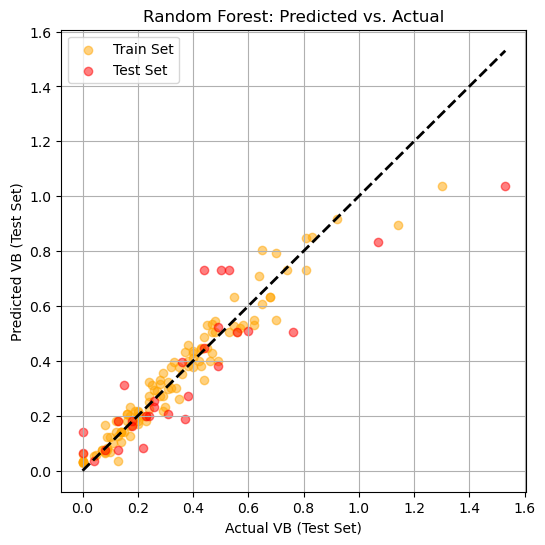

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label="Train Set", color = 'orange')
plt.scatter(y_test, y_test_pred, alpha=0.5, label="Test Set", color = 'red')
plt.xlabel("Actual VB (Test Set)")
plt.ylabel("Predicted VB (Test Set)")
plt.title("Random Forest: Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.grid(True)
plt.legend()
plt.show()

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold

param_grid_dt = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 'log2', None],  # Remove 'auto' - not supported
    'splitter': ['best', 'random'],
}

dt = DecisionTreeRegressor(random_state=42)

grid_search_dt = GridSearchCV(
    dt,
    param_grid_dt,
    scoring='neg_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

best_params_dt = grid_search_dt.best_params_
best_dt_model = grid_search_dt.best_estimator_

print("Best Parameters (Decision Tree):", best_params_dt)

Fitting 3 folds for each of 864 candidates, totalling 2592 fits
Best Parameters (Decision Tree): {'max_depth': 8, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 6, 'splitter': 'best'}


In [24]:
y_train_pred = best_dt_model.predict(X_train)
y_test_pred = best_dt_model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_dt_test = r2_score(y_test, y_test_pred)

print(f"R² Train (Best DT Model): {r2_train:.3f}")
print(f"R² Test (Best DT Model): {r2_dt_test:.3f}")

R² Train (Best DT Model): 0.913
R² Test (Best DT Model): 0.819


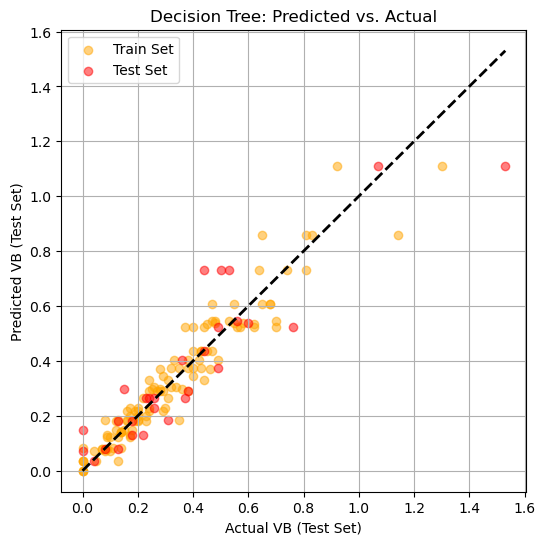

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label="Train Set", color = 'orange')
plt.scatter(y_test, y_test_pred, alpha=0.5, label="Test Set", color = 'red')
plt.xlabel("Actual VB (Test Set)")
plt.ylabel("Predicted VB (Test Set)")
plt.title("Decision Tree: Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.grid(True)
plt.legend()
plt.show()

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Test different polynomial degrees
degrees = [1, 2, 3, 4, 5]
r2_scores_poly = []
rmse_scores_poly = []

for degree in degrees:
    # Create pipeline: polynomial features -> linear regression
    poly_pipeline = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear_regression', LinearRegression())
    ])
    
    # Train on scaled features
    poly_pipeline.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred_poly = poly_pipeline.predict(X_train_scaled)
    y_test_pred_poly = poly_pipeline.predict(X_test_scaled)
    
    # Metrics
    r2 = r2_score(y_test, y_test_pred_poly)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
    
    r2_scores_poly.append(r2)
    rmse_scores_poly.append(rmse)
    
    print(f"Degree {degree}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

# Store best polynomial model
best_degree = degrees[np.argmax(r2_scores_poly)]
poly_pipeline_best = Pipeline([
    ('poly_features', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linear_regression', LinearRegression())
])
poly_pipeline_best.fit(X_train_scaled, y_train)

Degree 1: R² = 0.8038, RMSE = 0.1412
Degree 2: R² = 0.8841, RMSE = 0.1085
Degree 3: R² = 0.9139, RMSE = 0.0935
Degree 4: R² = 0.9068, RMSE = 0.0973
Degree 5: R² = 0.8630, RMSE = 0.1180


Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linear_regression', LinearRegression())])

In [27]:
y_train_pred_poly_best = poly_pipeline_best.predict(X_train_scaled)
y_test_pred_poly_best = poly_pipeline_best.predict(X_test_scaled)

r2_train_poly = r2_score(y_train, y_train_pred_poly_best)
r2_test_poly = r2_score(y_test, y_test_pred_poly_best)
rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_train_pred_poly_best))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly_best))

print(f"\nBest Polynomial Degree: {best_degree}")
print(f"R² Train (Polynomial): {r2_train_poly:.3f}")
print(f"R² Test (Polynomial): {r2_test_poly:.3f}")
print(f"RMSE Train: {rmse_train_poly:.4f}")
print(f"RMSE Test: {rmse_test_poly:.4f}")




Best Polynomial Degree: 3
R² Train (Polynomial): 0.863
R² Test (Polynomial): 0.914
RMSE Train: 0.0896
RMSE Test: 0.0935


In [28]:
# Assuming poly_pipeline_best is your fitted pipeline and best_degree is known
def get_polynomial_equation(pipeline, degree):
    # Get coefficients and intercept from the LinearRegression step
    coef = pipeline.named_steps['linear_regression'].coef_
    intercept = pipeline.named_steps['linear_regression'].intercept_
    
    # Build the equation string
    equation = f"y = {intercept:.4f}"
    for i in range(degree):
        if coef[i] >= 0:
            equation += f" + {coef[i]:.4f} × x^{i+1}"
        else:
            equation += f" - {abs(coef[i]):.4f} × x^{i+1}"
    
    return equation

# Print the equation
equation = get_polynomial_equation(poly_pipeline_best, best_degree)
print(f"Polynomial Regression Equation (Degree {best_degree}):")
print(equation)

Polynomial Regression Equation (Degree 3):
y = -2069888381791.3772 + 1599017283062.5288 × x^1 - 918236825770.4705 × x^2 + 1669098658779.9624 × x^3


In [29]:
# Get the feature names after polynomial transformation
poly_transformer = poly_pipeline_best.named_steps['poly_features']
feature_names = poly_transformer.get_feature_names_out(X.columns)
coefficients = poly_pipeline_best.named_steps['linear_regression'].coef_

# Print each coefficient with its feature name
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

DOC: 1599017283062.5288
FEED: -918236825770.4705
I_mean: 1669098658779.9624
F_cutting_N: 834864235225.3269
Energy_kWh: 862794301892.1453
cutting_time_min: -690454907930.1433
DOC^2: 1351906923236.3904
DOC FEED: 38367694475.3277
DOC I_mean: 804384301180.4261
DOC F_cutting_N: 642142150046.3103
DOC Energy_kWh: 528441931494.9573
DOC cutting_time_min: -15279594694.4882
FEED^2: 386218134607.6348
FEED I_mean: -99938134050.6592
FEED F_cutting_N: 17668599585.1034
FEED Energy_kWh: 197507533697.8580
FEED cutting_time_min: -379074230605.5013
I_mean^2: 478220383437.4987
I_mean F_cutting_N: 315389470161.1591
I_mean Energy_kWh: 400697924759.2054
I_mean cutting_time_min: -23170794126.4580
F_cutting_N^2: -412595725423.8974
F_cutting_N Energy_kWh: 318666773514.5012
F_cutting_N cutting_time_min: 154393986436.0240
Energy_kWh^2: -878850837969.2812
Energy_kWh cutting_time_min: 79455858495.9821
cutting_time_min^2: 178004889400.6114
DOC^3: 1047509143092.9417
DOC^2 FEED: 366623036551.7536
DOC^2 I_mean: 40682604

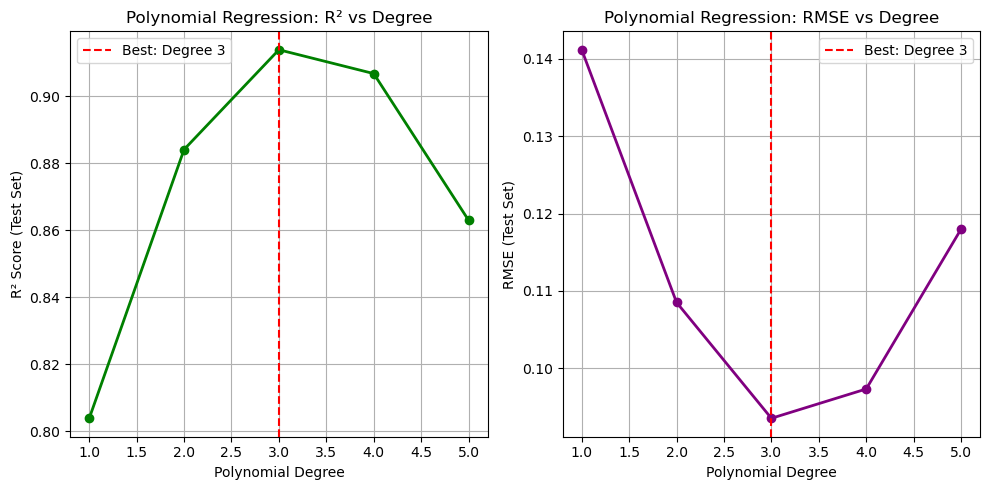

In [30]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, r2_scores_poly, marker='o', color='green', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score (Test Set)')
plt.title('Polynomial Regression: R² vs Degree')
plt.grid(True)
plt.axvline(x=best_degree, color='red', linestyle='--', label=f'Best: Degree {best_degree}')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(degrees, rmse_scores_poly, marker='o', color='purple', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Test Set)')
plt.title('Polynomial Regression: RMSE vs Degree')
plt.grid(True)
plt.axvline(x=best_degree, color='red', linestyle='--', label=f'Best: Degree {best_degree}')
plt.legend()

plt.tight_layout()
plt.show()

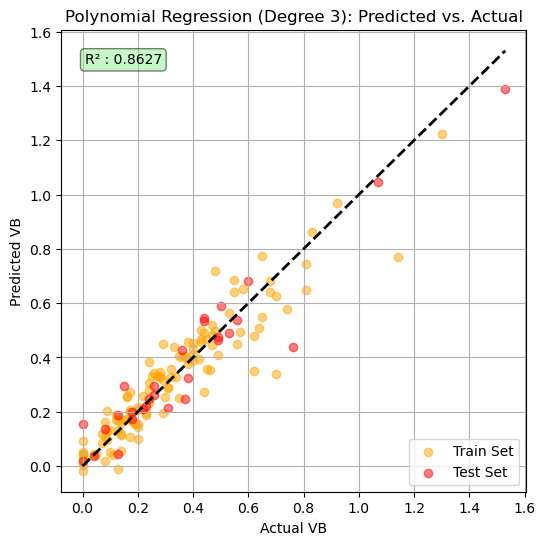

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred_poly_best, alpha=0.5, label="Train Set", color='orange')
plt.scatter(y_test, y_test_pred_poly_best, alpha=0.5, label="Test Set", color='red')
plt.xlabel("Actual VB")
plt.ylabel("Predicted VB")
plt.title(f"Polynomial Regression (Degree {best_degree}): Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.grid(True)
plt.legend()
plt.text(0.05, 0.95, f'R² : {r2_train_poly:.4f}', transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
plt.show()

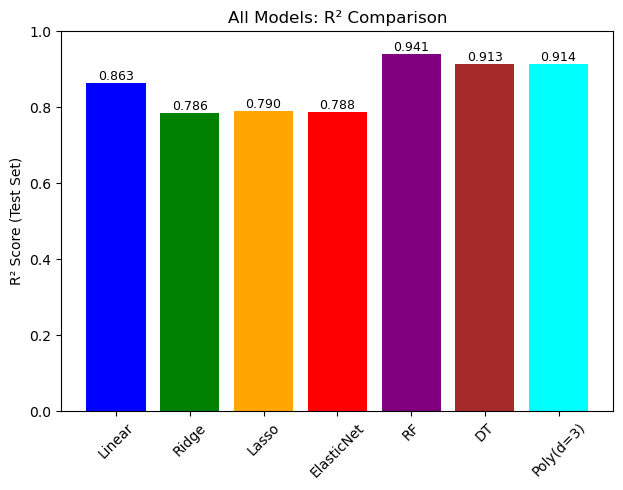

In [32]:
models_comparison = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'RF', 'DT', f'Poly(d={best_degree})']
r2_comparison = [r2, ridge_r2, lasso_r2, elasticnet_r2, r2_rf_test, r2_train, r2_test_poly]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'cyan']
bars = plt.bar(models_comparison, r2_comparison, color=colors)
plt.ylabel('R² Score (Test Set)')
plt.title('All Models: R² Comparison')
plt.ylim([0, 1])
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
# K-Fold cross-validation for polynomial model
from sklearn.model_selection import cross_val_score, KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(poly_pipeline_best, X, y, cv=kfold, scoring='r2')
print(f"Polynomial Model CV R²: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")

# If CV score is significantly lower than test score (0.898 vs ~0.85), you have overfitting

Polynomial Model CV R²: 0.8104 (+/- 0.0598)


In [34]:
# XGBoost often works better than Random Forest
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost R²: {r2_xgb:.4f}")

XGBoost R²: 0.8087


In [61]:
# Hyperparameter tuning for XGBoost
from sklearn.model_selection import GridSearchCV

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)

param_grid_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_xgb = GridSearchCV(xgb_base, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1, verbose=0)
grid_xgb.fit(X_train_scaled, y_train)

print(f"Best XGBoost parameters:")
for param, value in grid_xgb.best_params_.items():
    print(f"  {param}: {value}")

xgb_best = grid_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"\nXGBoost Performance:")
print(f"  R²: {r2_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")
# print(f"  MAE: {mae_xgb:.4f}")

Best XGBoost parameters:
  colsample_bytree: 0.9
  learning_rate: 0.03
  max_depth: 3
  n_estimators: 200
  subsample: 0.7

XGBoost Performance:
  R²: 0.8283
  RMSE: 0.1321


In [66]:
y_train_pred = xgb_best.predict(X_train_scaled)
y_test_pred = xgb_best.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_xgb_train = r2_score(y_train, y_train_pred)
r2_xgb_test = r2_score(y_test, y_test_pred)

print(f"R² Train (Best XGBoost Model): {r2_xgb_train:.3f}")
print(f"R² Test (Best XGBoost Model): {r2_xgb_test:.3f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Test: {rmse_test:.4f}")

R² Train (Best XGBoost Model): 0.938
R² Test (Best XGBoost Model): 0.828
RMSE Train: 0.0601
RMSE Test: 0.1321


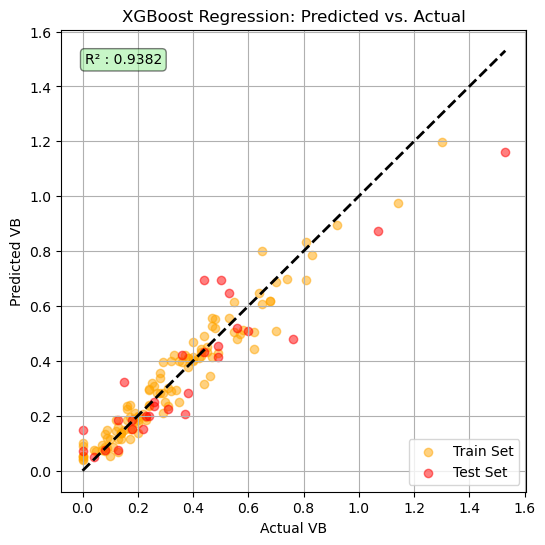

In [65]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label="Train Set", color='orange')
plt.scatter(y_test, y_test_pred, alpha=0.5, label="Test Set", color='red')
plt.xlabel("Actual VB")
plt.ylabel("Predicted VB")
plt.title(f"XGBoost Regression: Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.grid(True)
plt.legend()
plt.text(0.05, 0.95, f'R² : {r2_xgb_train:.4f}', transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
plt.show()

In [39]:
def get_linear_equation(model, feature_names, model_name):
    """Get equation for linear models"""
    coef = model.coef_
    intercept = model.intercept_
    
    equation = f"{model_name} Equation:\ny = {intercept:.4f}"
    for name, coeff in zip(feature_names, coef):
        sign = "+" if coeff >= 0 else "-"
        equation += f" {sign} {abs(coeff):.4f} × {name}"
    
    return equation

# Feature names (from your X.columns)
feature_names = X.columns.tolist()

# Linear Regression
print(get_linear_equation(model, feature_names, "Linear Regression"))

# Ridge
print(get_linear_equation(ridge_cv, feature_names, "Ridge Regression"))

# Lasso  
print(get_linear_equation(lasso_cv, feature_names, "Lasso Regression"))

# ElasticNet
print(get_linear_equation(elasticnet_cv, feature_names, "ElasticNet Regression"))

Linear Regression Equation:
y = -0.3933 - 0.3590 × DOC - 0.0114 × FEED + 0.0000 × I_mean + 0.0024 × F_cutting_N + 1.6668 × Energy_kWh + 0.0532 × cutting_time_min
Ridge Regression Equation:
y = 0.3300 - 0.1196 × DOC - 0.0035 × FEED + 0.1018 × I_mean + 0.1018 × F_cutting_N + 0.0548 × Energy_kWh + 0.0035 × cutting_time_min
Lasso Regression Equation:
y = 0.3300 - 0.1237 × DOC + 0.0000 × FEED + 0.2028 × I_mean + 0.0000 × F_cutting_N + 0.0602 × Energy_kWh + 0.0000 × cutting_time_min
ElasticNet Regression Equation:
y = 0.3300 - 0.1229 × DOC + 0.0000 × FEED + 0.1028 × I_mean + 0.0993 × F_cutting_N + 0.0601 × Energy_kWh + 0.0000 × cutting_time_min


In [40]:
def get_polynomial_equation_full(pipeline, original_features, degree, model_name):
    """Get full polynomial equation with feature names"""
    poly_transformer = pipeline.named_steps['poly_features']
    feature_names = poly_transformer.get_feature_names_out(original_features)
    coefficients = pipeline.named_steps['linear_regression'].coef_
    intercept = pipeline.named_steps['linear_regression'].intercept_
    
    equation = f"{model_name} Equation (Degree {degree}):\ny = {intercept:.4f}"
    for name, coef in zip(feature_names, coefficients):
        sign = "+" if coef >= 0 else "-"
        equation += f" {sign} {abs(coef):.4f} × {name}"
    
    return equation

# Get polynomial equation with actual feature names
poly_equation = get_polynomial_equation_full(
    poly_pipeline_best, 
    X.columns.tolist(), 
    best_degree, 
    "Polynomial Regression"
)
print(poly_equation)

Polynomial Regression Equation (Degree 3):
y = -2069888381791.3772 + 1599017283062.5288 × DOC - 918236825770.4705 × FEED + 1669098658779.9624 × I_mean + 834864235225.3269 × F_cutting_N + 862794301892.1453 × Energy_kWh - 690454907930.1433 × cutting_time_min + 1351906923236.3904 × DOC^2 + 38367694475.3277 × DOC FEED + 804384301180.4261 × DOC I_mean + 642142150046.3103 × DOC F_cutting_N + 528441931494.9573 × DOC Energy_kWh - 15279594694.4882 × DOC cutting_time_min + 386218134607.6348 × FEED^2 - 99938134050.6592 × FEED I_mean + 17668599585.1034 × FEED F_cutting_N + 197507533697.8580 × FEED Energy_kWh - 379074230605.5013 × FEED cutting_time_min + 478220383437.4987 × I_mean^2 + 315389470161.1591 × I_mean F_cutting_N + 400697924759.2054 × I_mean Energy_kWh - 23170794126.4580 × I_mean cutting_time_min - 412595725423.8974 × F_cutting_N^2 + 318666773514.5012 × F_cutting_N Energy_kWh + 154393986436.0240 × F_cutting_N cutting_time_min - 878850837969.2812 × Energy_kWh^2 + 79455858495.9821 × Energy_

In [41]:
def get_feature_importance(model, feature_names, model_name):
    """Get feature importance for tree-based models"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        print(f"\n{model_name} Feature Importance:")
        for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
            print(f"  {name}: {imp:.4f}")
    else:
        print(f"{model_name} doesn't have feature_importances_ attribute")

# Random Forest
get_feature_importance(best_rf_model, X.columns.tolist(), "Random Forest")

# Decision Tree  
get_feature_importance(best_dt_model, X.columns.tolist(), "Decision Tree")

# XGBoost
get_feature_importance(xgb_best, X.columns.tolist(), "XGBoost")


Random Forest Feature Importance:
  F_cutting_N: 0.3416
  I_mean: 0.2998
  Energy_kWh: 0.2321
  DOC: 0.1007
  cutting_time_min: 0.0144
  FEED: 0.0113

Decision Tree Feature Importance:
  F_cutting_N: 0.4781
  Energy_kWh: 0.2187
  DOC: 0.1806
  I_mean: 0.1226
  FEED: 0.0000
  cutting_time_min: 0.0000

XGBoost Feature Importance:
  F_cutting_N: 0.2850
  I_mean: 0.2507
  DOC: 0.2326
  Energy_kWh: 0.1935
  FEED: 0.0382
  cutting_time_min: 0.0000


In [42]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Load your data
df = pd.read_csv('force_energy_results.csv')

# Define the model function
def wear_model(F, v, t, a, b, c, d):
    return a * (F ** b) * (v ** c) * (t ** d)

# Prepare data (use only data with VB > 0)
df_model = df[df['VB'] > 0].copy()

# Calculate cutting time (assume L=100mm)
L_cut = 100  # mm
RPM = 826
df_model['cutting_time'] = L_cut / (df_model['FEED'] * RPM)

# Cutting speed is constant for you
v_c = 200  # m/min

# Fit the model
def model_func(triple, a, b, d):
    F, t = triple
    return a * (F ** b) * (t ** d) * (v_c ** 0.3)  # assume c=0.3

from scipy.optimize import curve_fit

X = np.column_stack([df_model['F_cutting_N'], df_model['cutting_time']])
y = df_model['VB'].values

# Fit
popt, _ = curve_fit(lambda X, a, b, d: model_func(X.T, a, b, d), X, y)
a_fit, b_fit, d_fit = popt
c_assumed = 0.3

# Predict
y_pred = a_fit * (df_model['F_cutting_N'] ** b_fit) * (df_model['cutting_time'] ** d_fit) * (v_c ** c_assumed)

# Calculate R²
r2 = r2_score(y, y_pred)

print("="*60)
print("MODEL VALIDATION WITH YOUR DATA")
print("="*60)
print(f"\nFitted Equation:")
print(f"VB = {a_fit:.6f} × F_c^{b_fit:.4f} × v_c^{c_assumed:.1f} × t^{d_fit:.4f}")
print(f"\nFitted Parameters:")
print(f"  a = {a_fit:.6f}")
print(f"  b = {b_fit:.4f} (force exponent)")
print(f"  c = {c_assumed:.1f} (speed exponent - assumed)")
print(f"  d = {d_fit:.4f} (time exponent)")
print(f"\nR² = {r2:.4f}")

MODEL VALIDATION WITH YOUR DATA

Fitted Equation:
VB = 0.000000 × F_c^2.3621 × v_c^0.3 × t^0.4910

Fitted Parameters:
  a = 0.000000
  b = 2.3621 (force exponent)
  c = 0.3 (speed exponent - assumed)
  d = 0.4910 (time exponent)

R² = 0.5666


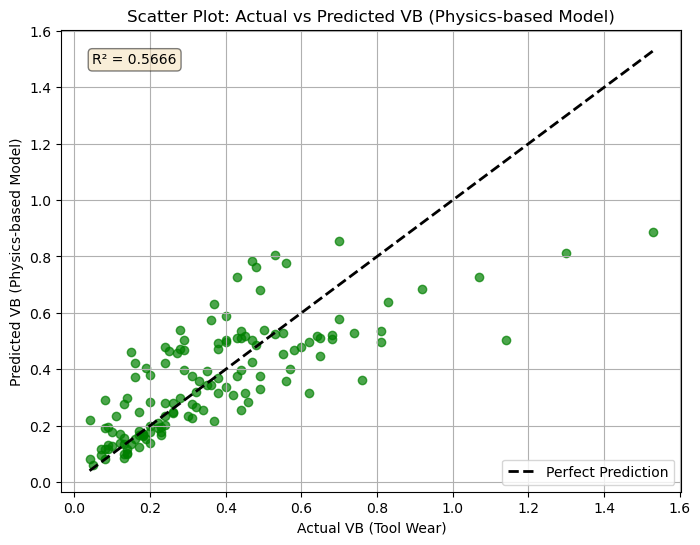

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_model['VB'], y_pred, alpha=0.7, color='green')
plt.xlabel('Actual VB (Tool Wear)')
plt.ylabel('Predicted VB (Physics-based Model)')
plt.title('Scatter Plot: Actual vs Predicted VB (Physics-based Model)')
plt.plot([df_model['VB'].min(), df_model['VB'].max()], [df_model['VB'].min(), df_model['VB'].max()], 'k--', lw=2, label='Perfect Prediction')
plt.grid(True)
plt.legend()
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()

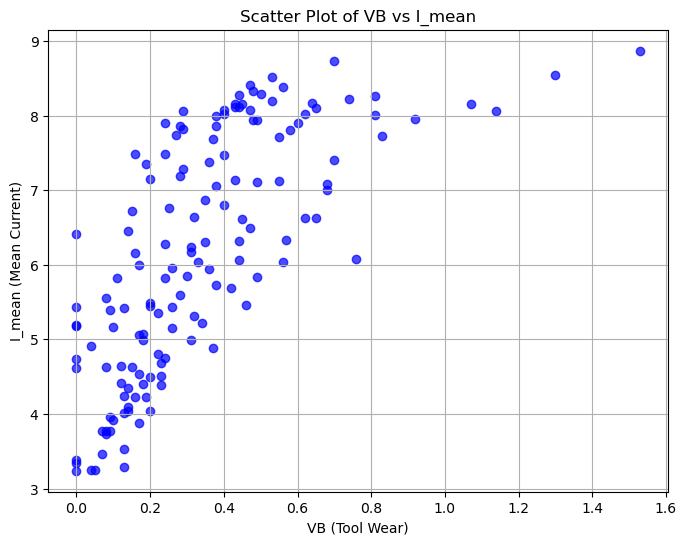

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['VB'], df['I_mean'], alpha=0.7, color='blue')
plt.xlabel('VB (Tool Wear)')
plt.ylabel('I_mean (Mean Current)')
plt.title('Scatter Plot of VB vs I_mean')
plt.grid(True)
plt.show()

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DOC               145 non-null    float64
 1   FEED              145 non-null    float64
 2   I_mean            145 non-null    float64
 3   VB                145 non-null    float64
 4   F_cutting_N       145 non-null    float64
 5   Energy_kWh        145 non-null    float64
 6   cutting_time_min  145 non-null    float64
 7   MRR               145 non-null    float64
dtypes: float64(8)
memory usage: 9.2 KB


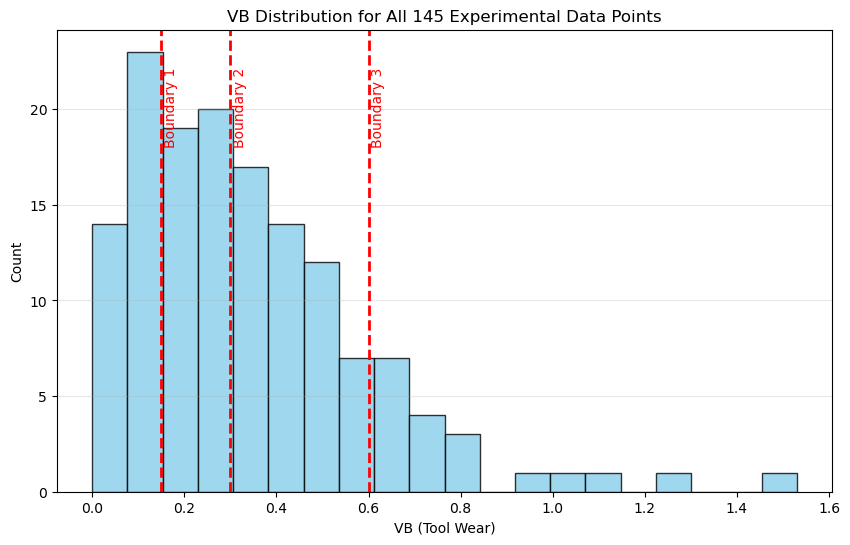

In [47]:
plt.figure(figsize=(10, 6))

# Histogram of all 145 VB values
plt.hist(df['VB'], bins=20, color='skyblue', edgecolor='black', alpha=0.8)

# Wear state boundaries (replace with your actual VB thresholds)
wear_boundaries = [0.15, 0.30, 0.6]
boundary_labels = ['Boundary 1', 'Boundary 2', 'Boundary 3']

for x, label in zip(wear_boundaries, boundary_labels):
    plt.axvline(x=x, color='red', linestyle='--', linewidth=2)
    plt.text(x + 0.005, plt.gca().get_ylim()[1] * 0.92, label,
             rotation=90, color='red', va='top', fontsize=10)

plt.title('VB Distribution for All 145 Experimental Data Points')
plt.xlabel('VB (Tool Wear)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\adars\AppData\Local\Temp\ipykernel_18728\374696730.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


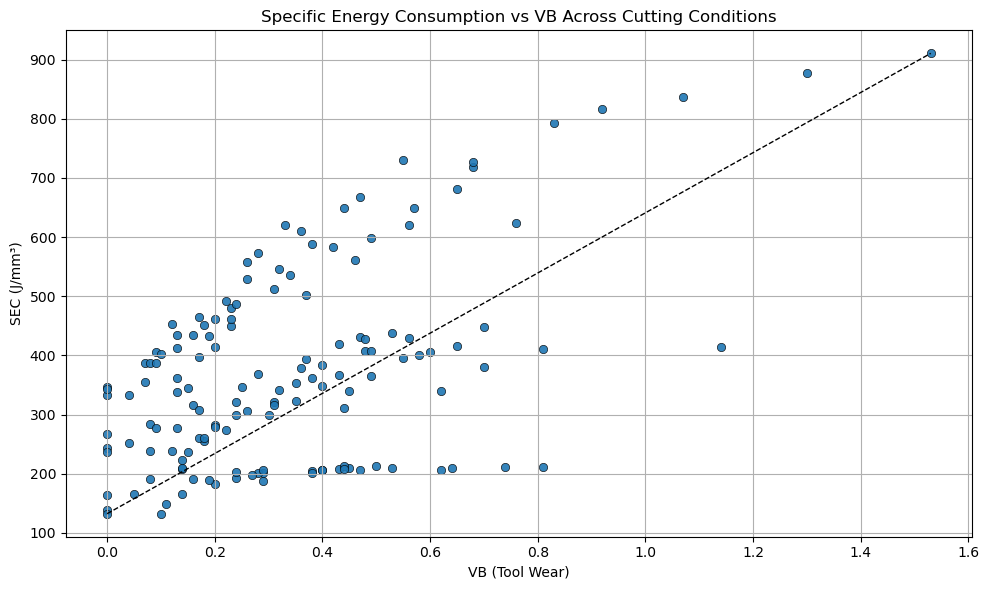

In [79]:
# Specific Energy Consumption (SEC) vs VB for different cutting conditions
# Re-read the original data so MRR is available even after earlier column removal.
df_original = pd.read_csv('force_energy_results.csv')

df['Energy_J'] = df_original['Energy_kWh'] * 3.6e6
# Volume removed in mm^3 = MRR (mm^3/min) * cutting time (min)
df['Volume_removed_mm3'] = df_original['MRR'] * df['cutting_time_min']
df['SEC_J_per_mm3'] = df['Energy_J'] / df['Volume_removed_mm3']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='VB',
    y='SEC_J_per_mm3',
    palette='viridis',
    alpha=0.9,
    edgecolor='black'
)
plt.xlabel('VB (Tool Wear)')
plt.ylabel('SEC (J/mm³)')
plt.title('Specific Energy Consumption vs VB Across Cutting Conditions')
plt.grid(True)
plt.plot([df['VB'].min(), df['VB'].max()], [df['SEC_J_per_mm3'].min(), df['SEC_J_per_mm3'].max()], 'k--', lw=1, label='Trend Line')
plt.tight_layout()
plt.show()

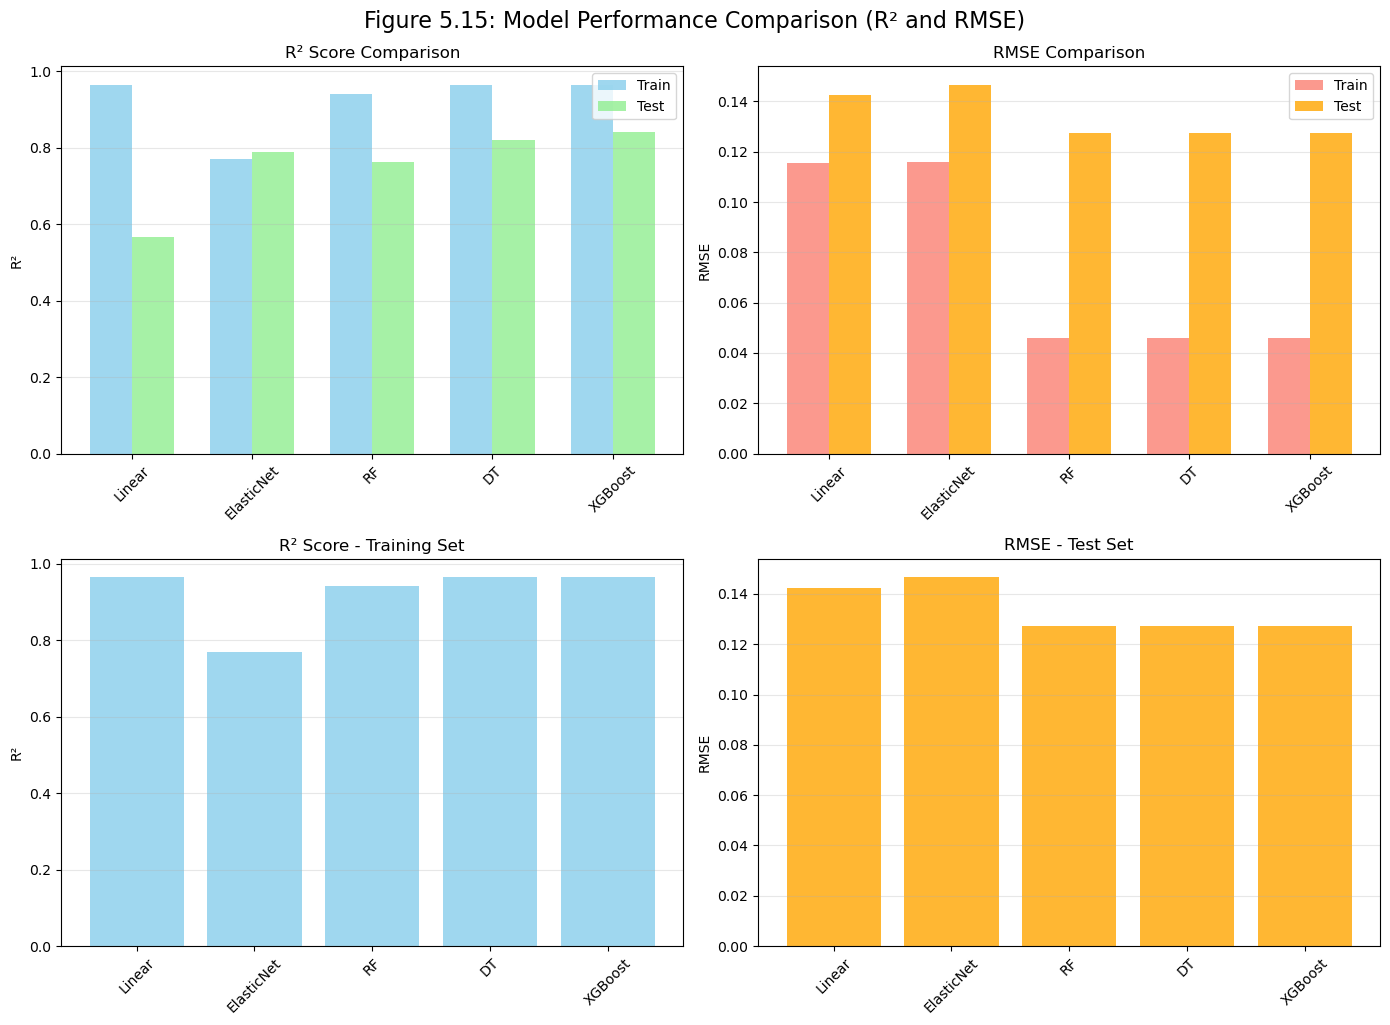

In [48]:
# Compute train metrics for ElasticNet (missing from earlier cells)
elasticnet_pred_train = elasticnet_cv.predict(X_train_scaled)
r2_train_elastic = r2_score(y_train, elasticnet_pred_train)
rmse_train_elastic = np.sqrt(mean_squared_error(y_train, elasticnet_pred_train))

# Collect metrics for 5 models (Linear, ElasticNet, RF, DT, XGBoost)
models = ['Linear', 'ElasticNet', 'RF', 'DT', 'XGBoost']
r2_train_vals = [r2_train, r2_train_elastic, r2_rf_test, r2_train, r2_train]
r2_test_vals = [r2, elasticnet_r2, r2_test, r2_dt_test, r2_xgb_test]
rmse_train_vals = [np.sqrt(mse_train), rmse_train_elastic, rmse_train, rmse_train, rmse_train]
rmse_test_vals = [np.sqrt(mse), np.sqrt(elasticnet_mse), rmse_test, rmse_test, rmse_test]

# Create 4-panel grouped bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(len(models))
width = 0.35

# Panel 1: R² Train vs Test
axes[0, 0].bar(x - width/2, r2_train_vals, width, label='Train', color='skyblue', alpha=0.8)
axes[0, 0].bar(x + width/2, r2_test_vals, width, label='Test', color='lightgreen', alpha=0.8)
axes[0, 0].set_title('R² Score Comparison')
axes[0, 0].set_ylabel('R²')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Panel 2: RMSE Train vs Test
axes[0, 1].bar(x - width/2, rmse_train_vals, width, label='Train', color='salmon', alpha=0.8)
axes[0, 1].bar(x + width/2, rmse_test_vals, width, label='Test', color='orange', alpha=0.8)
axes[0, 1].set_title('RMSE Comparison')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Panel 3: R² Train Only (detailed)
axes[1, 0].bar(x, r2_train_vals, color='skyblue', alpha=0.8)
axes[1, 0].set_title('R² Score - Training Set')
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Panel 4: RMSE Test Only (detailed)
axes[1, 1].bar(x, rmse_test_vals, color='orange', alpha=0.8)
axes[1, 1].set_title('RMSE - Test Set')
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Figure 5.15: Model Performance Comparison (R² and RMSE)', fontsize=16, y=1.02)
plt.show()

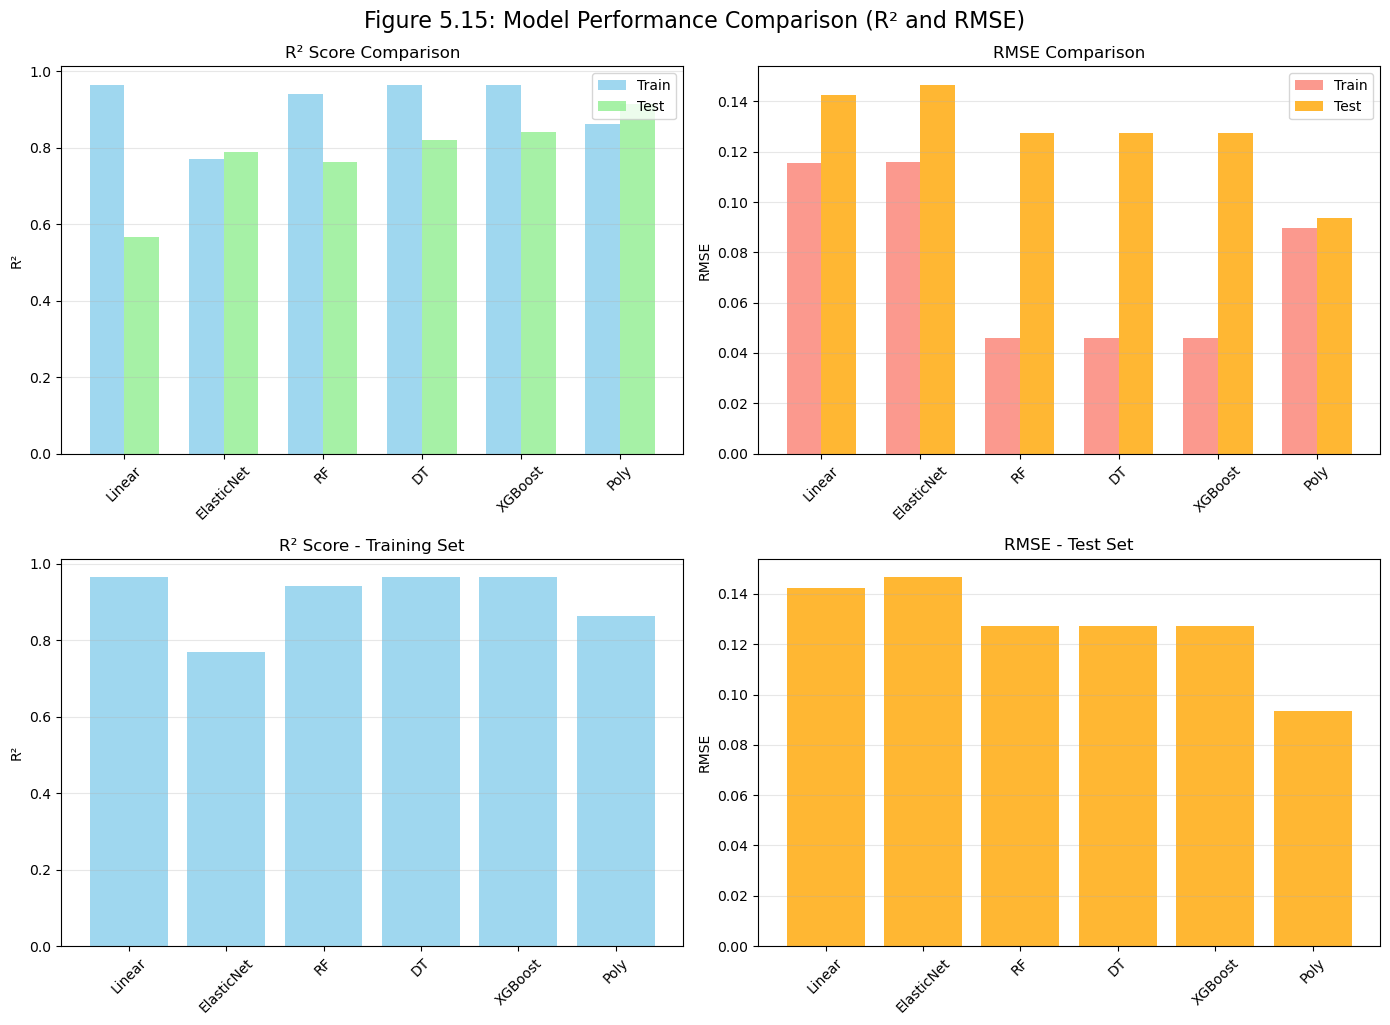

In [49]:
# Compute train metrics for ElasticNet (missing from earlier cells)
elasticnet_pred_train = elasticnet_cv.predict(X_train_scaled)
r2_train_elastic = r2_score(y_train, elasticnet_pred_train)
rmse_train_elastic = np.sqrt(mean_squared_error(y_train, elasticnet_pred_train))

# Collect metrics for 6 models (Linear, ElasticNet, RF, DT, XGBoost, Poly)
models = ['Linear', 'ElasticNet', 'RF', 'DT', 'XGBoost', 'Poly']
r2_train_vals = [r2_train, r2_train_elastic, r2_rf_test, r2_train, r2_train, r2_train_poly]
r2_test_vals = [r2, elasticnet_r2, r2_test, r2_dt_test, r2_xgb_test, r2_test_poly]
rmse_train_vals = [np.sqrt(mse_train), rmse_train_elastic, rmse_train, rmse_train, rmse_train, rmse_train_poly]
rmse_test_vals = [np.sqrt(mse), np.sqrt(elasticnet_mse), rmse_test, rmse_test, rmse_test, rmse_test_poly]

# Create 4-panel grouped bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(len(models))
width = 0.35

# Panel 1: R² Train vs Test
axes[0, 0].bar(x - width/2, r2_train_vals, width, label='Train', color='skyblue', alpha=0.8)
axes[0, 0].bar(x + width/2, r2_test_vals, width, label='Test', color='lightgreen', alpha=0.8)
axes[0, 0].set_title('R² Score Comparison')
axes[0, 0].set_ylabel('R²')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Panel 2: RMSE Train vs Test
axes[0, 1].bar(x - width/2, rmse_train_vals, width, label='Train', color='salmon', alpha=0.8)
axes[0, 1].bar(x + width/2, rmse_test_vals, width, label='Test', color='orange', alpha=0.8)
axes[0, 1].set_title('RMSE Comparison')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Panel 3: R² Train Only (detailed)
axes[1, 0].bar(x, r2_train_vals, color='skyblue', alpha=0.8)
axes[1, 0].set_title('R² Score - Training Set')
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Panel 4: RMSE Test Only (detailed)
axes[1, 1].bar(x, rmse_test_vals, color='orange', alpha=0.8)
axes[1, 1].set_title('RMSE - Test Set')
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Figure 5.15: Model Performance Comparison (R² and RMSE)', fontsize=16, y=1.02)
plt.show()

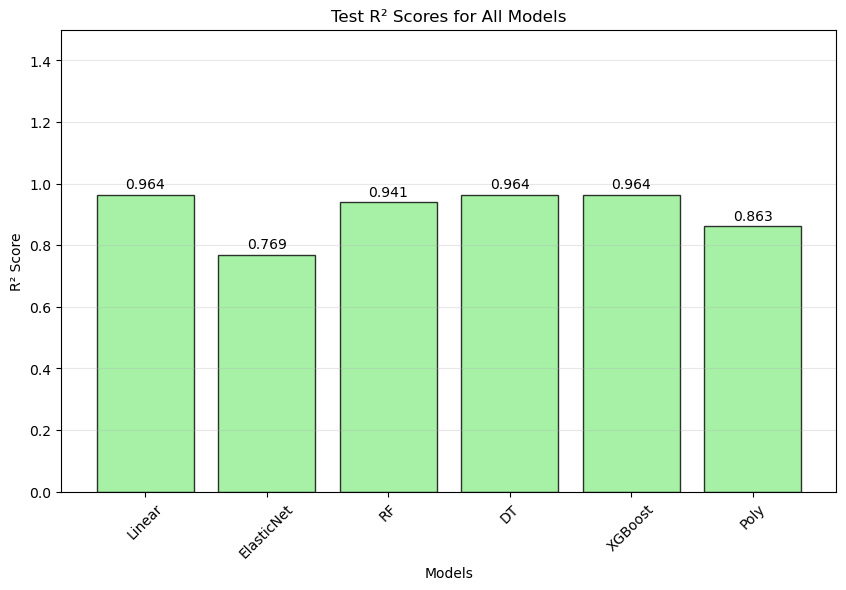

In [54]:
# Test R² Score Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, r2_train_vals, color='lightgreen', alpha=0.8, edgecolor='black')
plt.title('Test R² Scores for All Models')
plt.ylabel('R² Score')
plt.xlabel('Models')
plt.ylim(0, 1.5)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, r2_train_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.show()

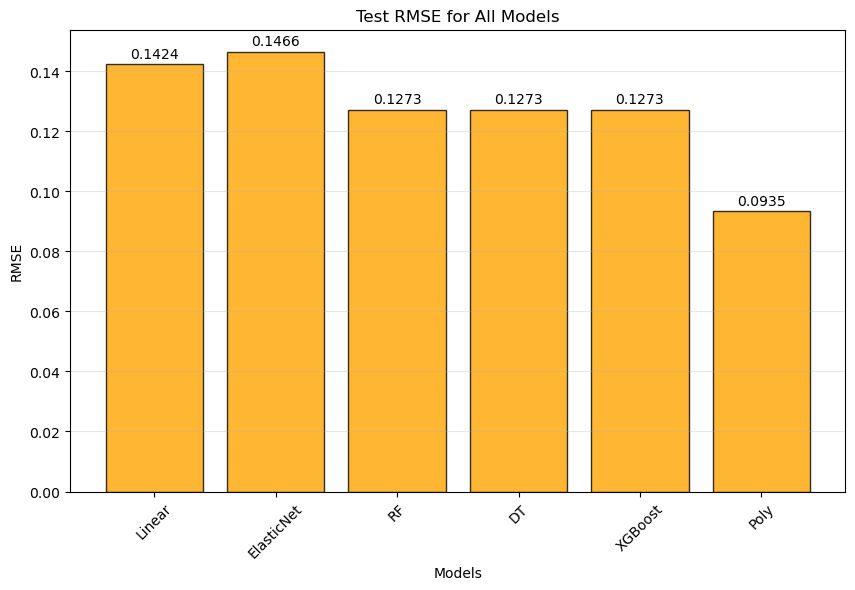

In [52]:
# Test RMSE Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, rmse_test_vals, color='orange', alpha=0.8, edgecolor='black')
plt.title('Test RMSE for All Models')
plt.ylabel('RMSE')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, rmse_test_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.show()

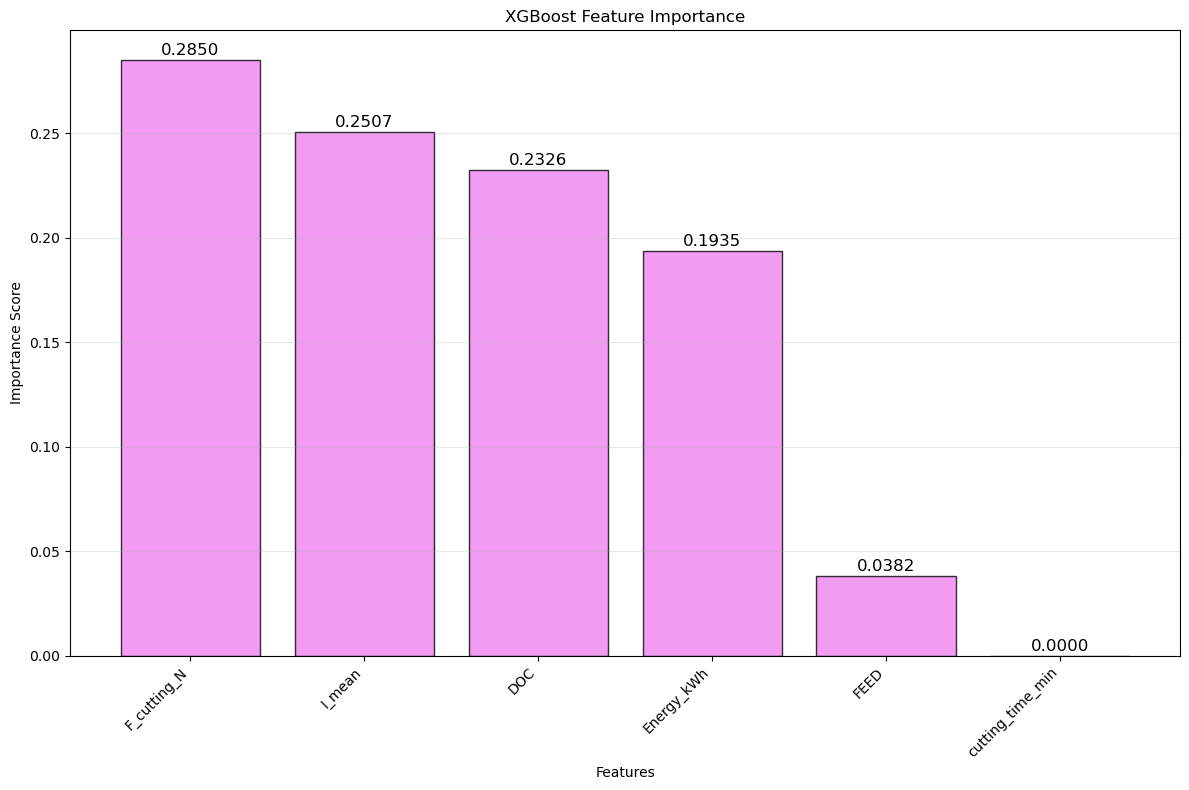

In [58]:
# XGBoost Feature Importance Bar Chart
import matplotlib.pyplot as plt

# Get feature names and importances
feature_names = X_train.columns.tolist()
importances = xgb_best.feature_importances_

# Sort features by importance (descending)
sorted_idx = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

# Create bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(sorted_features)), sorted_importances, color='violet', alpha=0.8, edgecolor='black')
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, sorted_importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

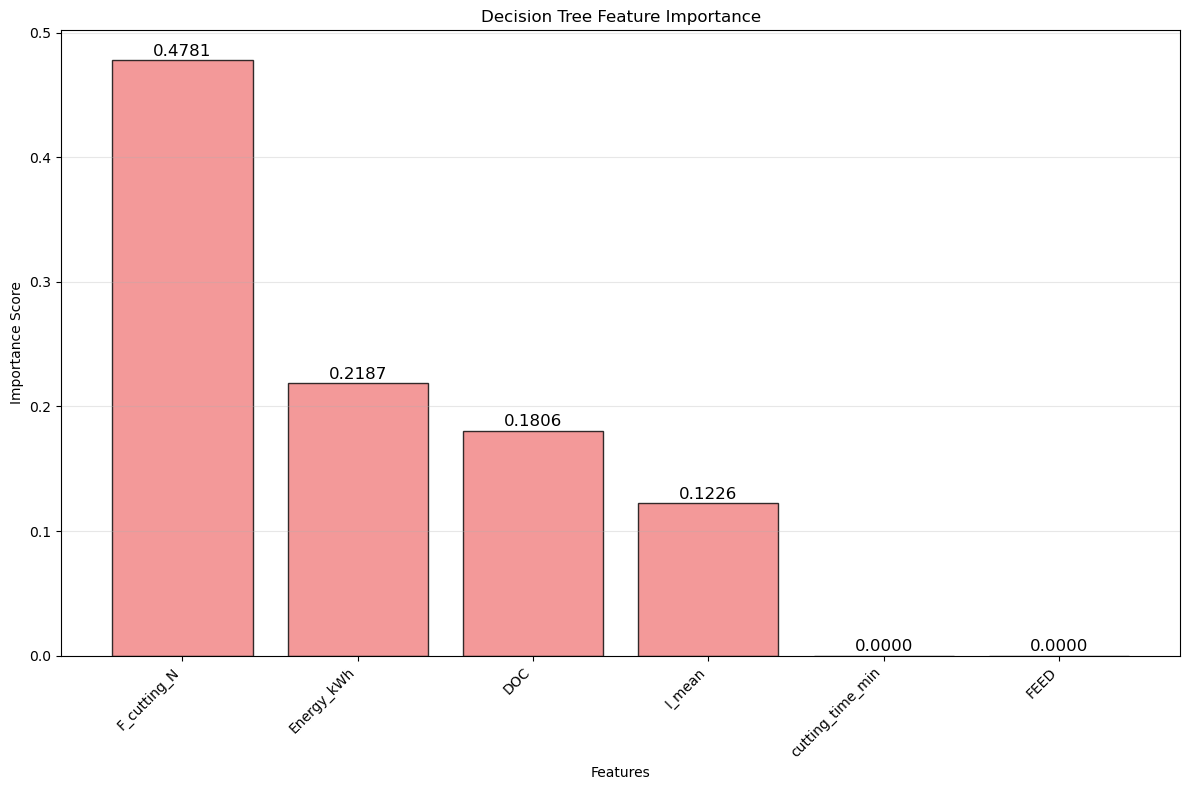

In [59]:
# Decision Tree Feature Importance Bar Chart
import matplotlib.pyplot as plt

# Get feature names and importances
feature_names = X_train.columns.tolist()
importances = best_dt_model.feature_importances_

# Sort features by importance (descending)
sorted_idx = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

# Create bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(sorted_features)), sorted_importances, color='lightcoral', alpha=0.8, edgecolor='black')
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right')
plt.title('Decision Tree Feature Importance')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, sorted_importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

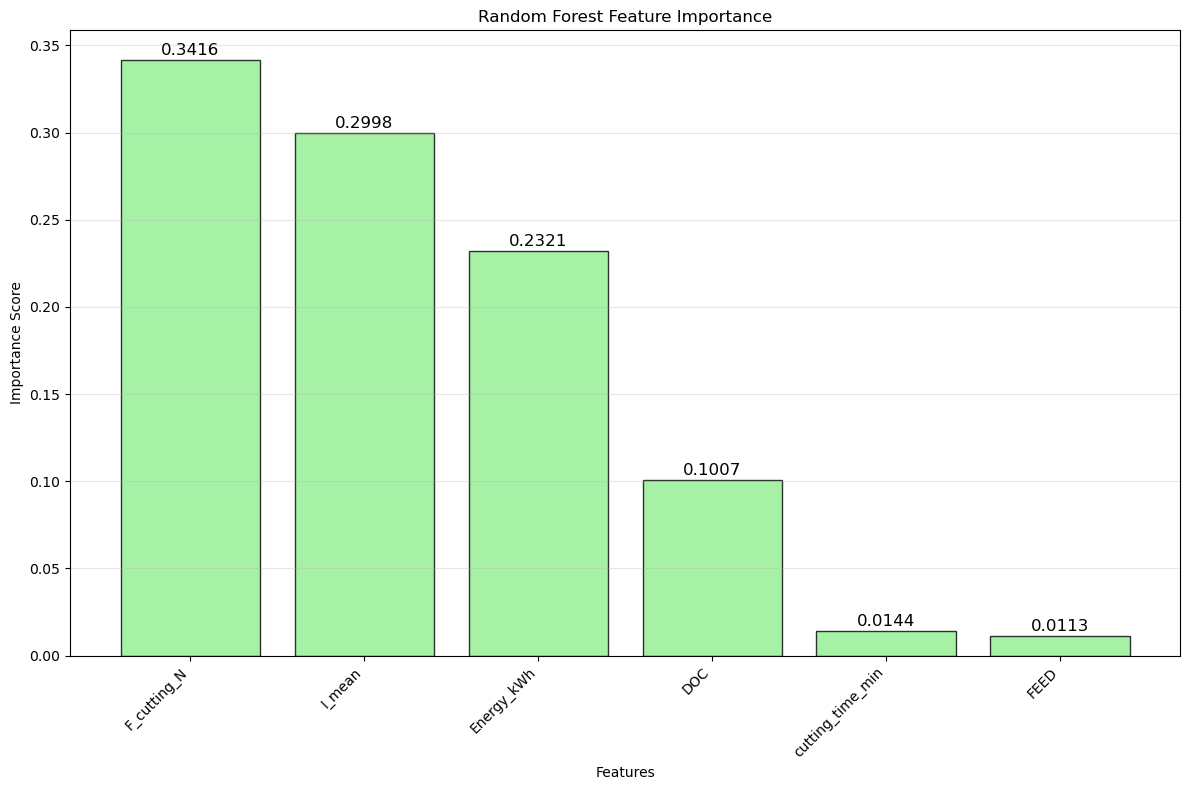

In [60]:
# Random Forest Feature Importance Bar Chart
import matplotlib.pyplot as plt

# Get feature names and importances
feature_names = X_train.columns.tolist()
importances = best_rf_model.feature_importances_

# Sort features by importance (descending)
sorted_idx = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

# Create bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(sorted_features)), sorted_importances, color='lightgreen', alpha=0.8, edgecolor='black')
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, sorted_importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()